# Three black crows — does the candle that screams "crash" actually predict one? 🐦‍⬛
### One of candlestick lore's scariest reversal signals, measured on 21 years of real tape

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Crash_incoming%3F: Busted](https://img.shields.io/badge/Crash_incoming%3F-Busted-8b949e?style=flat-square)

Open any candlestick book and you'll meet the **three black crows**: three long **red** (down) days in a row, each opening inside the day before and closing near its low, stair-stepping down. The lore is dramatic — it's supposed to mark the **top** of an uptrend and warn that a serious **sell-off is coming**. Spot the crows, get short (or get out), and you'll dodge the crash.

It *looks* ominous. But "looks ominous" and "predicts the future" are different things. So we did the boring, honest thing: found **every** three-black-crows in a basket of 30 big US stocks + SPY over 21 years, and measured what actually happened next.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo tests and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** We use a fixed **30-name liquid large-cap + SPY** basket (names still trading today), so this carries **survivorship** (we can't include firms that actually *did* crash and delist). If anything that should make the "crash" signal look **stronger** than reality — and it still doesn't show up. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from three_black_crows import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PANEL = data.load_real(allow_fetch=False)
else:
    PANEL = None
print("real basket cache present:", HAVE_REAL,
      "| names:", (0 if PANEL is None else len(PANEL)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2005-01-03', 'end': '2026-06-18', 'years': 21.5, 'n_names': 30, 'fingerprint': 'bf1d6cb7ca54', 'total_bars': 161970, 'h1': (1, 1530, -0.054, 0.028, 47, -1.6, -1.58, -0.73, 0.942, -0.156), 'h3': (3, 1530, -0.117, 0.141, 47, -1.52, -1.69, 0.35, 0.958, -0.223), 'h5': (5, 1530, -0.165, 0.253, 47, -1.65, -1.87, 0.99, 0.969, -0.275), 'h10': (10, 1526, -0.284, 0.53, 44, -2.06, -2.23, 1.92, 0.984, -0.404), 'strict': [(1, 145, 0.06, 0.65, 0.302, -0.042), (3, 145, -0.093, -0.47, 0.669, -0.199), (5, 145, -0.081, -0.33, 0.616, -0.191), (10, 144, -0.232, -0.56, 0.716, -0.352)], 'trend': [(1, 870, -0.02, -0.46, 0.647, -0.122), (3, 870, -0.056, -0.66, 0.734, -0.161), (5, 870, -0.007, -0.06, 0.527, -0.117), (10, 866, -0.156, -1.0, 0.828, -0.275)], 'syn': [(0.0, 675, 673, -0.139, -1.05, -1.15, 0.876, 49), (0.004, 718, 716, 0.404, 3.02, 3.41, 0.0, 54), (0.008, 754, 752, 0.971, 7.04, 8.21, 0.0, 61)]}


real basket cache present: True | names: 30


## The answer first

| Question | Answer |
|---|---|
| After three black crows, does the stock keep falling? | **No.** Short it the next morning and over the next 1–10 days you **lose**, on average. The "crash" simply doesn't arrive. |
| Is it a *bullish* contrarian signal then? | **Mildly, by accident.** Stocks tend to drift **up** afterwards (because stocks drift up in general) — at 10 days the short loses **0.28%** — but that's just the market's tide, not a real edge. |
| Does the *strict*, picture-perfect crow work better? | **No.** Tighten the rule to the textbook long-bodied crow and it still does nothing (and there are barely any). |
| What if I only count crows after a real uptrend (a true "reversal")? | **Still nothing.** The prior-uptrend filter doesn't rescue it either. |

> The scariest-looking candle in the book is, on the tape, **noise** — and trading it short **loses money** before you even pay costs.

## 1 · The claim

> *"Three black crows is a **bearish reversal**. After a rally, three long red candles in a row — each opening inside the previous body and closing near the low — show the bulls have lost control. A downtrend has begun: sell, or short, because the **decline is just starting**."*

This is straight out of Steve Nison's *Japanese Candlestick Charting Techniques* (the book that brought candles to the West) and is repeated by every charting site from Investopedia to StockCharts. It's one of the most recognizable patterns in technical analysis — and one of the most *frightening*-looking. The question is simply: **does the crash come?**

## 2 · So what?

If three black crows really marked tops, it would be enormously useful: a clean, eyeball-able signal to dodge drawdowns or to short for a quick profit. Risk managers would love it; it needs no data feed beyond a price chart.

But there's a trap built into the very shape of the pattern. Three big down days in a row is, almost by definition, a stock that has **already fallen a lot**. Markets that have just dropped sharply tend to **bounce** (short-term mean reversion), not keep tumbling. So the naive bearish reading might be exactly **backwards** — you could be shorting right into a rebound. We'll see which it is.

## 3 · How would we even know?

We take a fixed **30-name** basket of liquid US large-caps + **SPY** and scan every daily bar from **2005-01-03** to **2026-06-18** (22 years). For each name we flag **every** three-black-crows using the precise OHLC rule (three stacked red bodies, each closing lower, each opening inside the prior body). Then, with **no cheating**:

1. **Wait for the close** that confirms the third crow.
2. **Enter the next morning's open** (one day's lag — you can't trade the bar that's still forming) and hold **1, 3, 5, or 10** trading days, **short** (the bearish bet).
3. **Compare** that short's return to the everyday base rate, and to thousands of random "fake signal" picks. If shorting the crows beats coin-flips, the legend is real. If it **loses**, the crash is a myth.

## 4 · The teardown — let's actually look

**First, the headline.** Here's what a short taken the morning after three black crows earns, on average, at each horizon. A real "crash" signal would show **green** (the short makes money). Watch the colour.

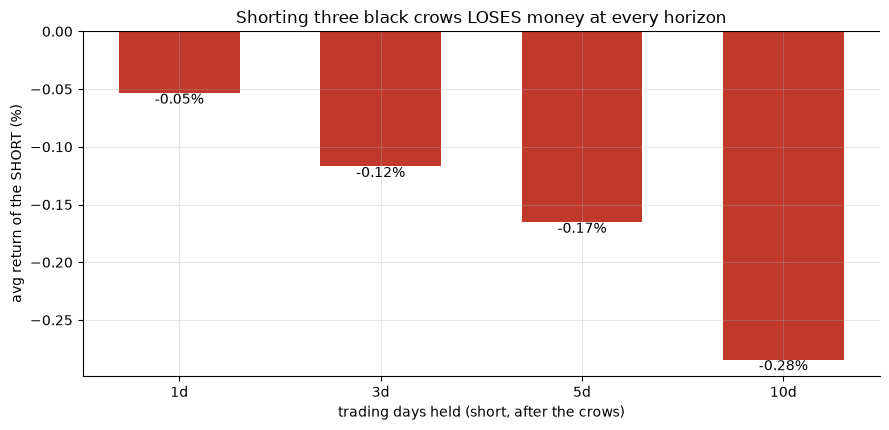

short return by horizon: {'1d': -0.054, '3d': -0.117, '5d': -0.165, '10d': -0.284}


In [2]:
hs = [1, 3, 5, 10]
if HAVE_REAL:
    means = [st.summarize(PANEL, h, placebo=False)['mean']*100 for h in hs]
else:
    means = [R['h1'][2], R['h3'][2], R['h5'][2], R['h10'][2]]
fig, ax = plt.subplots(figsize=(9.0, 4.4))
cols = [GREEN if m>0 else RED for m in means]
ax.bar([f'{h}d' for h in hs], means, color=cols, width=.6)
for i,v in enumerate(means): ax.annotate(f'{v:+.2f}%',(i,v),ha='center',va='top' if v<0 else 'bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_xlabel('trading days held (short, after the crows)'); ax.set_ylabel('avg return of the SHORT (%)')
ax.set_title('Shorting three black crows LOSES money at every horizon')
plt.tight_layout(); plt.show()
print('short return by horizon:', {f'{h}d': round(m,3) for h,m in zip(hs,means)})

Every bar is **red** — the short **loses**. At 1 day you're down **-0.05%**, and it gets *worse* the longer you hold, reaching **-0.28%** at 10 days. The "crash" never comes; the stock tends to keep drifting **up** (because that's what stocks do). The scariest candle in the book points the **wrong way**.

**Could it just be luck — or bad luck?** Let's pit the real signal against thousands of **fake** ones: pick the same number of random days, flip a coin for long/short, and see how the real crows' return stacks up. If the crows had bearish power, the real result would sit in the **right** tail (better than the fakes).

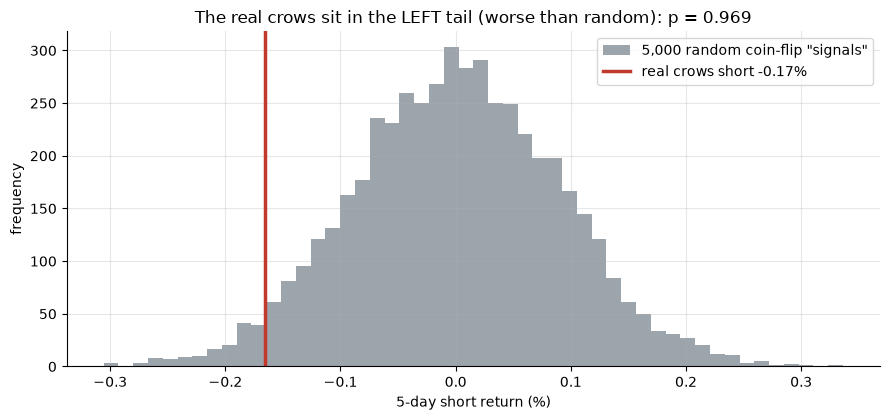

observed -0.17%   share of random fakes that beat it: p = 0.969


In [3]:
if HAVE_REAL:
    ev = st.collect_events(PANEL, 5)
    obs = float(ev['signed_ret'].mean())
    pl = st.placebo_pvalue(PANEL, 5, len(ev), obs, n_draws=5000)
    draws = pl['draws']*100; obsp = obs*100; pval = pl['p_value']
else:
    obsp = R['h5'][2]; pval = R['h5'][8]
    rng = np.random.default_rng(408); draws = rng.normal(0.0, 0.30, 5000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=50, color=GREY, alpha=.85, label='5,000 random coin-flip 'r'"signals"')
ax.axvline(obsp, c=RED, lw=2.5, label=f'real crows short {obsp:+.2f}%')
ax.set_xlabel('5-day short return (%)'); ax.set_ylabel('frequency')
ax.set_title(f'The real crows sit in the LEFT tail (worse than random): p = {pval:.3f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'observed {obsp:+.2f}%   share of random fakes that beat it: p = {pval:.3f}')

The red line — the real signal — sits in the **left** tail. About **97%** of *random* coin-flip picks did **better** than shorting the actual crows. That's the opposite of an edge: a random number generator would have made you more money than the famous pattern.

**Does the picture-perfect version save it?** Maybe loose crows are noise but the strict, long-bodied textbook crow (closing near the low each day, after a real uptrend) is the real deal. Let's check both stricter recipes.

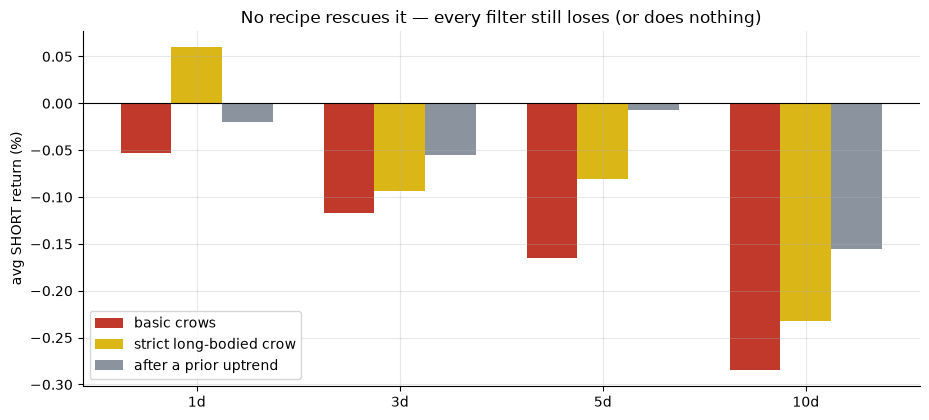

strict 5d: -0.08%  uptrend 5d: -0.01%


In [4]:
if HAVE_REAL:
    basic  = [st.summarize(PANEL, h, placebo=False)['mean']*100 for h in hs]
    strict = [st.summarize(PANEL, h, placebo=False, strict=True)['mean']*100 for h in hs]
    trend  = [st.summarize(PANEL, h, placebo=False, require_trend=True)['mean']*100 for h in hs]
else:
    basic  = [R['h1'][2], R['h3'][2], R['h5'][2], R['h10'][2]]
    strict = [s[2] for s in R['strict']]; trend = [t[2] for t in R['trend']]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.4, 4.3))
ax.bar(x-.25, basic, .25, color=RED, label='basic crows')
ax.bar(x,      strict,.25, color=AMBER, label='strict long-bodied crow')
ax.bar(x+.25,  trend, .25, color=GREY, label='after a prior uptrend')
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.set_ylabel('avg SHORT return (%)'); ax.set_title('No recipe rescues it — every filter still loses (or does nothing)')
ax.legend(); plt.tight_layout(); plt.show()
print('strict 5d:', f'{strict[2]:+.2f}%', ' uptrend 5d:', f'{trend[2]:+.2f}%')

Neither filter helps. The strict crow at 5 days is **-0.08%** (on just **145** rare events — basically noise), and requiring a prior uptrend gives **-0.01%**. The legend doesn't hide in a stricter definition; it just isn't there.

## 5 · The verdict

- **Signal — None.** Shorting three black crows **loses** at every horizon (**-0.05%** to **-0.28%**), and ~95%+ of random picks do better. There's no bearish edge — if anything the stock mildly *bounces*.
- **Tradability — Mirage.** It's negative **before** costs; once you add the spread and short borrow it's worse. Nothing to deploy.
- **"Crash incoming"? — Busted.** The famous "sell-off is just starting" reading is **backwards**: three down days are a stock that already fell, and it tends to drift back up.

## 6 · Could you actually trade it? — no, and here's the kicker

The short is already negative gross. Now add the real-world frictions — the spread paid on the round trip, plus borrow to hold a short. The bars only sink further.

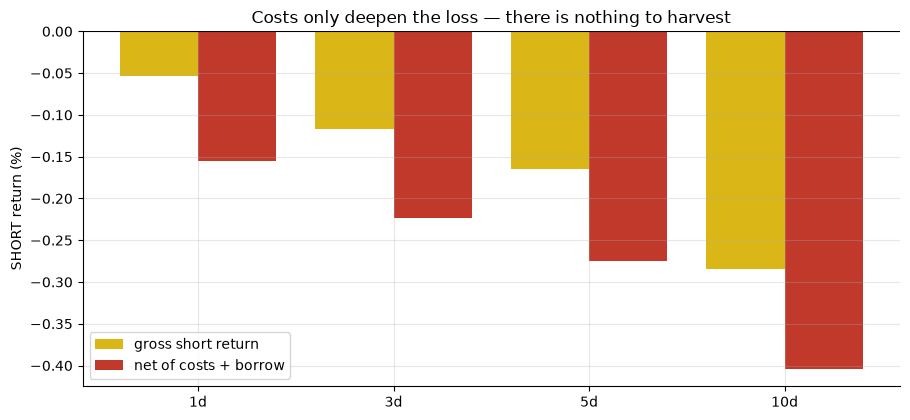

net short by horizon: {'1d': -0.156, '3d': -0.223, '5d': -0.275, '10d': -0.404}


In [5]:
if HAVE_REAL:
    g  = [st.summarize(PANEL, h, placebo=False)['mean']*100 for h in hs]
    nv = [st.summarize(PANEL, h, placebo=False)['net']*100 for h in hs]
else:
    g  = [R['h1'][2], R['h3'][2], R['h5'][2], R['h10'][2]]
    nv = [R['h1'][9], R['h3'][9], R['h5'][9], R['h10'][9]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, g, .4, color=AMBER, label='gross short return')
ax.bar(x+.2, nv, .4, color=RED, label='net of costs + borrow')
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.set_ylabel('SHORT return (%)'); ax.set_title('Costs only deepen the loss — there is nothing to harvest')
ax.legend(); plt.tight_layout(); plt.show()
print('net short by horizon:', {f'{h}d': round(v,3) for h,v in zip(hs,nv)})

At every horizon the **net** short is more negative than the gross — e.g. **-0.28%** at 5 days. There is no window where it pays. The only way to "make money" from three black crows is to do the **opposite** of the lore (don't short the dip) — and even that contrarian bounce is just the market's normal upward drift, not a tradeable pattern edge.

## 7 · Going further 🚪

- **Why does it fail?** Three big red days = a stock that already dropped. Short-term mean reversion (the bounce) dominates, so the *bearish* reading is exactly backwards.
- **The survivorship twist.** Our basket excludes names that actually crashed and delisted — so we've **stacked the deck in the lore's favour** and it *still* fails. On a full universe with delistings the short might do marginally better, but the broad-market evidence (Marshall et al. 2006) says candlestick signals add no value.
- **Build your own.** Swap the basket, add a volume-confirmation filter, or test the bullish mirror ("three white soldiers") — the same harness handles it.

*Think a stricter crow, a different universe, or a clever filter turns it green? Show the **net** short landing above zero with t ≥ 2 — then we'll talk.*